## Task#1: Thresholding

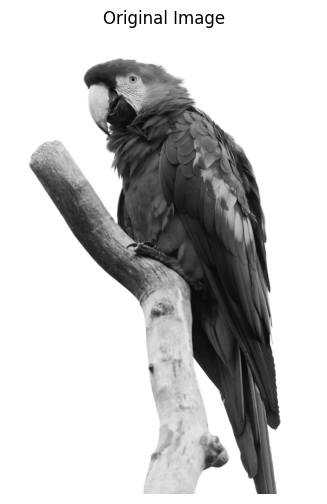

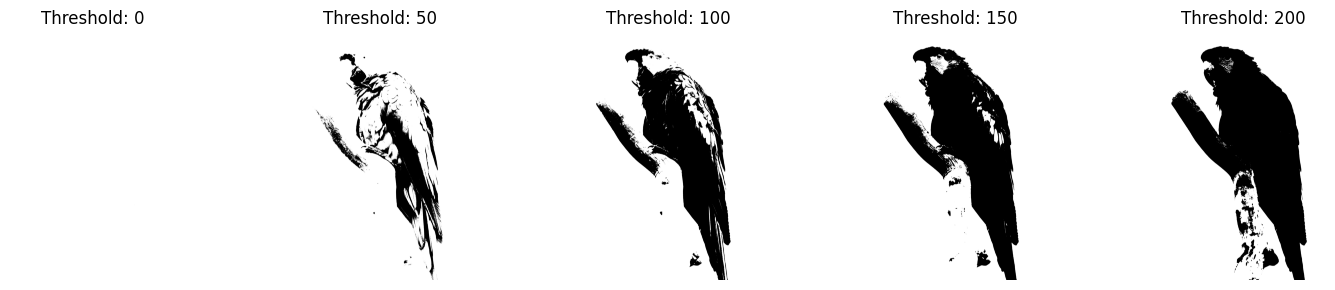

In [2]:
import cv2
import matplotlib.pyplot as plt

# Load the image in grayscale
img = cv2.imread('Pics\\Parrot_RGB.jpg', cv2.IMREAD_GRAYSCALE)

# Display the original image
plt.figure(figsize=(8, 6))
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with different threshold values
fig, axes = plt.subplots(1, len(threshold_values), figsize=(15, 3))
for idx, threshold_value in enumerate(threshold_values):
    ret, thresh = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)
    axes[idx].imshow(thresh, cmap='gray')
    axes[idx].set_title(f'Threshold: {threshold_value}')
    axes[idx].axis('off')
plt.tight_layout()
plt.show() #plt to make it show in the notebook instead of popup

## Task#2: Histogram Processing

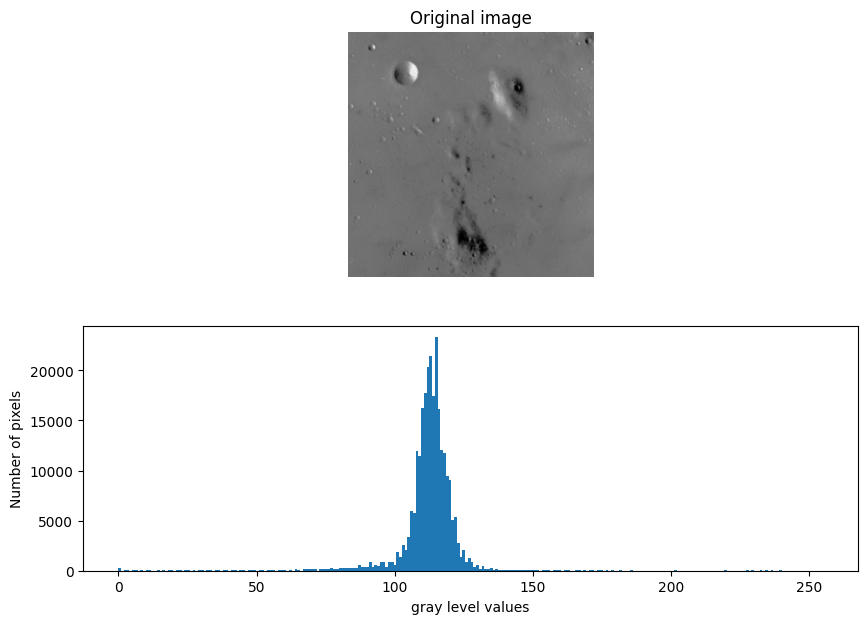

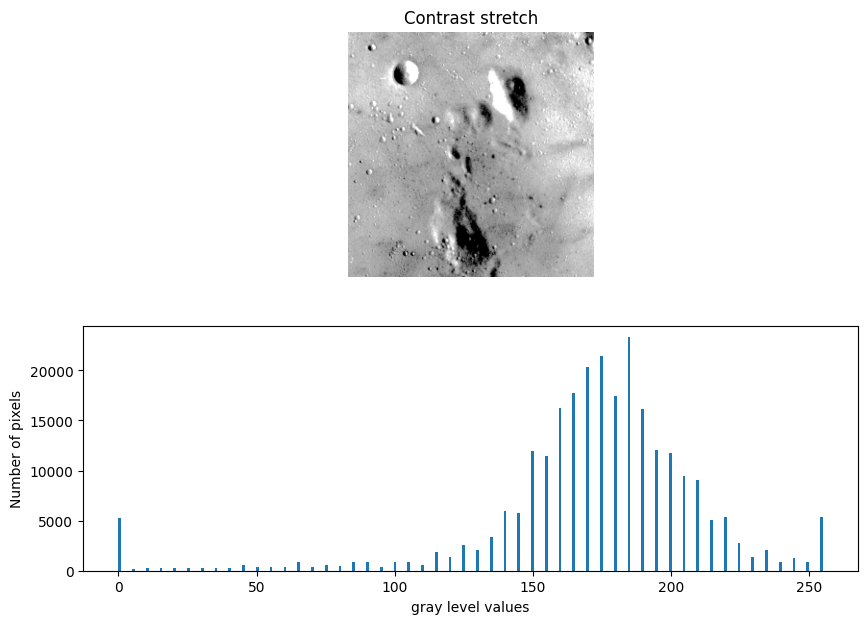

In [1]:
# Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data, img_as_float
from skimage import exposure

# Step#2: Load moon image
img = data.moon()

# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

# Step#4: Display the image with its histogram of (step#2)  and (step#3)

fig = plt.figure(figsize=(10, 7)) 
fig.add_subplot(2, 1, 1) 
plt.imshow(img, cmap = 'gray') 
plt.axis('off') 
plt.title('Original image') 
fig.add_subplot(2, 1, 2) 
plt.hist(img.flat, bins = 256, range=(0, 255)) 
plt.xlabel('gray level values') 
plt.ylabel('Number of pixels') 
plt.show() 



fig = plt.figure(figsize=(10, 7)) 	
fig.add_subplot(2, 1, 1) 
plt.imshow(img_rescale, cmap = 'gray') 
plt.axis('off') 
plt.title('Contrast stretch')
fig.add_subplot(2, 1, 2) 
plt.hist(img_rescale.flat, bins = 256, range=(0, 255)) 
plt.xlabel('gray level values') 
plt.ylabel('Number of pixels') 
plt.show()



## Task#3: Histogram Matching

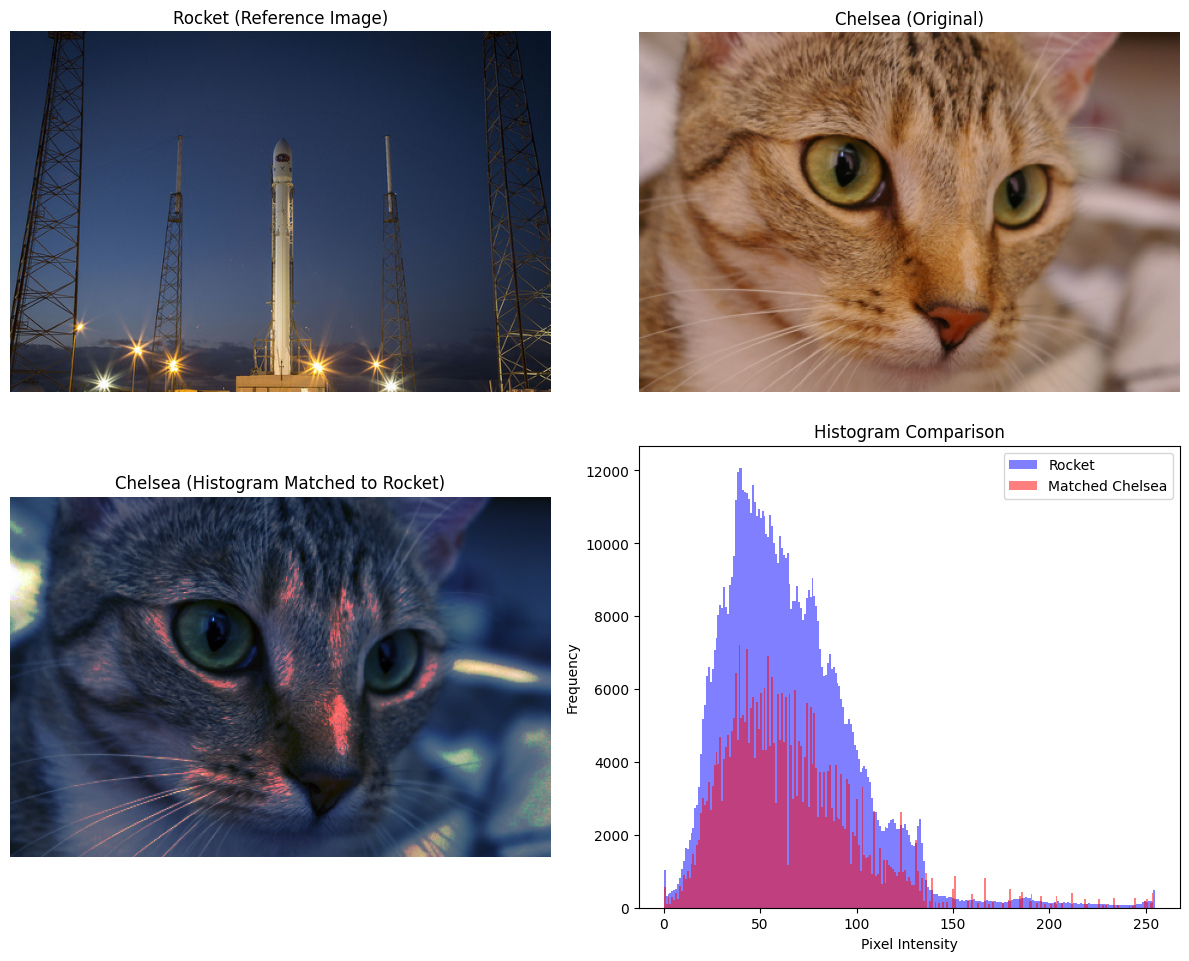

In [2]:
# Step#1: Load necessary libraries
import matplotlib.pyplot as plt
import numpy as np
from skimage import data
from skimage.exposure import match_histograms

# Step#2: Load rocket (reference) and chelsea images
rocket = data.rocket()
chelsea = data.chelsea()

# Step#3: Match histogram of chelsea to rocket
matched = match_histograms(chelsea, rocket, channel_axis=-1)

# Step#4: Display the images and results
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Original rocket (reference)
axes[0, 0].imshow(rocket)
axes[0, 0].set_title('Rocket (Reference Image)')
axes[0, 0].axis('off')

# Original chelsea
axes[0, 1].imshow(chelsea)
axes[0, 1].set_title('Chelsea (Original)')
axes[0, 1].axis('off')

# Matched chelsea
axes[1, 0].imshow(matched)
axes[1, 0].set_title('Chelsea (Histogram Matched to Rocket)')
axes[1, 0].axis('off')

# Histogram comparison
axes[1, 1].hist(rocket.flat, bins=256, alpha=0.5, label='Rocket', color='blue')
axes[1, 1].hist(matched.flat, bins=256, alpha=0.5, label='Matched Chelsea', color='red')
axes[1, 1].set_xlabel('Pixel Intensity')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Histogram Comparison')
axes[1, 1].legend()

plt.tight_layout()
plt.show()